# 🔬 Metadata Enrichment in RAG Pipelines
## From Sparse Chunks to Precision Retrieval with LangExtract + LangChain

**Audience:** Advanced — you know RAG, embeddings, and LangChain basics.  
This notebook focuses entirely on the **metadata enrichment layer** and how it transforms retrieval quality.

**What you will build:**
```
Raw text chunks (2 metadata fields)
    → LangExtract enrichment  (LLM extracts structured metadata per chunk)
    → Rich documents (10+ metadata fields)
    → 4 retrieval strategies  (basic → filtered → scored → self-query)
    → Measurable improvement in retrieval precision + timing data
```

| Section | Topic | API Calls |
|---------|-------|-----------|
| 0 | Setup | None |
| 1 | The Sparse Metadata Problem | None |
| 2 | LangExtract Under the Hood | None |
| 3 | Chunk-Level vs Document-Level Extraction | None |
| 4 | Live Enrichment Pipeline | ✅ `OPENAI_API_KEY` |
| 5 | Four Retrieval Strategies Head-to-Head | ✅ `OPENAI_API_KEY` |
| 6 | Metadata in the LLM Context | ✅ `OPENAI_API_KEY` |
| 7 | Exercises with Solutions | ✅ `OPENAI_API_KEY` |

> **Only `OPENAI_API_KEY` is required. No Pinecone needed — we use Chroma (in-memory) throughout.**


---
## Section 0 — Setup


In [ ]:
# Install dependencies (uses uv — the project's package manager)
# Skip if running inside the project's .venv
!uv pip install -q langchain langchain-openai langchain-chroma langextract[openai] chromadb python-dotenv pandas matplotlib


In [1]:
import sys
import json
import time
import os
import textwrap
import inspect
from itertools import zip_longest
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
matplotlib.rcParams['figure.figsize'] = (10, 4)

from IPython.display import HTML, display
from langchain_core.documents import Document

# Add project root to path so we can import from ingest/ and retrieval/
PROJECT_ROOT = Path('../').resolve()
sys.path.insert(0, str(PROJECT_ROOT))
print(f'Project root: {PROJECT_ROOT}')
print('Core imports OK')


Project root: /Users/sourangshupal/Downloads/langextract-rag
Core imports OK


In [2]:
from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / '.env')

api_key = os.getenv('OPENAI_API_KEY', '')
if api_key:
    print(f'OPENAI_API_KEY loaded: {api_key[:8]}...')
else:
    print('WARNING: OPENAI_API_KEY not found.')
    print('  Sections 1-3 run fine. Sections 4+ require the key.')
    print('  Set it in ../.env or export OPENAI_API_KEY=sk-...')


OPENAI_API_KEY loaded: sk-proj-...


---
## Section 1 — The Sparse Metadata Problem

When you load a PDF and chunk it with `RecursiveCharacterTextSplitter`, each chunk gets
exactly **two metadata fields**: `source` (filename) and `page` (page number).

Let's build a corpus of 8 synthetic documents spanning **3 different categories**
(technical API docs, legal terms, financial pricing) and make the sparseness concrete.


In [3]:
# 8 synthetic documents — no PDF, no API calls
# Intentionally spans 3 categories so metadata filtering has a clear payoff later

raw_documents = [
    # ── Technical: API Reference ──────────────────────────────────────────────
    Document(
        page_content=(
            'Section 3.2: Authentication API v2.1 — Released January 2025. '
            'The OAuth2 module supports client_credentials and authorization_code flows. '
            'Maximum token lifetime is 3600 seconds. '
            'Contact the Platform Engineering team for API key provisioning.'
        ),
        metadata={'source': 'api_ref.pdf', 'page': 1},
    ),
    Document(
        page_content=(
            'Rate Limits (API v2.1): Standard tier — 100 requests/min. '
            'Premium tier — 1000 requests/min. Enterprise tier — unlimited. '
            'Exceeded limits return HTTP 429. Use the Retry-After header for backoff.'
        ),
        metadata={'source': 'api_ref.pdf', 'page': 2},
    ),
    Document(
        page_content=(
            'Webhook Integration v3.0 — Configure endpoint URLs in the developer dashboard. '
            'Supported events: payment.completed, payment.failed, refund.issued. '
            'HMAC-SHA256 signature verification required for all webhook endpoints.'
        ),
        metadata={'source': 'api_ref.pdf', 'page': 3},
    ),
    # ── Legal: Terms of Service ────────────────────────────────────────────────
    Document(
        page_content=(
            'Section 12: Limitation of Liability. In no event shall the Company be liable '
            'for indirect, incidental, special, or consequential damages. '
            'Customer acknowledges services are provided as-is without warranty of any kind.'
        ),
        metadata={'source': 'legal_terms.pdf', 'page': 5},
    ),
    Document(
        page_content=(
            'Section 15: Governing Law. This Agreement shall be governed by Delaware law. '
            'Any disputes resolved through binding arbitration in San Francisco, CA, '
            'under JAMS Arbitration Rules.'
        ),
        metadata={'source': 'legal_terms.pdf', 'page': 6},
    ),
    Document(
        page_content=(
            'Section 8: Data Processing Agreement. Customer grants Company a license to '
            'process data solely to provide the services. GDPR Article 28 compliance maintained. '
            'Data retention period: 90 days post-termination.'
        ),
        metadata={'source': 'legal_terms.pdf', 'page': 8},
    ),
    # ── Financial: Pricing ─────────────────────────────────────────────────────
    Document(
        page_content=(
            'Enterprise Pricing (2025): Base platform fee $500/month. '
            'API calls billed at $0.01 per 1,000 requests. '
            'Storage: $0.023/GB-month. Premium SLA at $1,200/month. Annual commitment: 15% off.'
        ),
        metadata={'source': 'pricing.pdf', 'page': 1},
    ),
    Document(
        page_content=(
            'Volume Discounts: 1M-10M calls/month: 10% off. 10M-100M calls/month: 20% off. '
            '100M+ calls/month: 30% off. Custom enterprise contracts for 1B+ calls. '
            'Contact sales@example.com for custom pricing.'
        ),
        metadata={'source': 'pricing.pdf', 'page': 2},
    ),
]

print(f'Created {len(raw_documents)} documents')
print(f'Sources: {sorted(set(d.metadata["source"] for d in raw_documents))}')


Created 8 documents
Sources: ['api_ref.pdf', 'legal_terms.pdf', 'pricing.pdf']


In [4]:
# Display as pandas DataFrame — observe how sparse the metadata is
rows = []
for i, doc in enumerate(raw_documents):
    rows.append({
        'idx': i,
        'source': doc.metadata['source'],
        'page': doc.metadata['page'],
        'content_preview': doc.page_content[:75] + '...',
    })

df_raw = pd.DataFrame(rows)
display(df_raw.style.set_caption('Raw documents — only source and page as metadata'))

all_keys = set()
for doc in raw_documents:
    all_keys.update(doc.metadata.keys())

print(f'Unique metadata fields per document: {sorted(all_keys)}')
print(f'--> Only {len(all_keys)} field(s)!')


,idx,source,page,content_preview
0,0,api_ref.pdf,1,Section 3.2: Authentication API v2.1 — Released January 2025. The OAuth2 mo...
1,1,api_ref.pdf,2,Rate Limits (API v2.1): Standard tier — 100 requests/min. Premium tier — 10...
2,2,api_ref.pdf,3,Webhook Integration v3.0 — Configure endpoint URLs in the developer dashboa...
3,3,legal_terms.pdf,5,Section 12: Limitation of Liability. In no event shall the Company be liabl...
4,4,legal_terms.pdf,6,Section 15: Governing Law. This Agreement shall be governed by Delaware law...
5,5,legal_terms.pdf,8,Section 8: Data Processing Agreement. Customer grants Company a license to ...
6,6,pricing.pdf,1,Enterprise Pricing (2025): Base platform fee $500/month. API calls billed a...
7,7,pricing.pdf,2,Volume Discounts: 1M-10M calls/month: 10% off. 10M-100M calls/month: 20% of...


Unique metadata fields per document: ['page', 'source']
--> Only 2 field(s)!


### The Challenge

With only `source` and `page`, you **cannot answer** any of these queries precisely:

| Query | Filter needed | Possible with current metadata? |
|-------|--------------|--------------------------------|
| *Show me only technical API documentation* | `category == 'technical'` | ❌ No such field |
| *Find API docs from version 2.1* | `version == 'v2.1'` | ❌ No such field |
| *Legal documents only* | `category == 'legal'` | ❌ No such field |
| *What did the OAuth2 team publish?* | `entities contains 'OAuth2'` | ❌ No such field |

Every query devolves to **pure semantic search** — mixing technical, legal, and financial results based solely on vector similarity. The semantic space can't distinguish *relevance to category* from *relevance to query*.

> **Section 4 will add 8+ new metadata fields per chunk. Section 5 will show exactly what that unlocks.**


---
## Section 2 — LangExtract Under the Hood

LangExtract (by Google) is an extraction library that calls an LLM with a structured prompt
and returns typed `Extraction` objects. The project's `metadata_extractor.py` wraps it.

**No API calls in this section** — we read module code and simulate extraction with mock objects.


In [5]:
from ingest.metadata_extractor import (
    DEFAULT_EXTRACTION_PROMPT,
    DEFAULT_EXAMPLES,
    _parse_extractions,
)

print('=== EXTRACTION PROMPT SENT TO THE LLM ===')
print()
print(DEFAULT_EXTRACTION_PROMPT)


=== EXTRACTION PROMPT SENT TO THE LLM ===

Extract structured metadata from the given text document chunk.
For each chunk, identify:
- document_topic: The primary topic/subject of this text
- document_category: The category (e.g., technical, legal, financial, medical, general)
- key_entities: Important named entities (people, organizations, products, locations)
- document_version: Any version numbers or dates mentioned
- summary: A 1-2 sentence summary of this chunk

Use exact text for extractions where possible. Do not paraphrase or infer
information not present in the text.



/Users/sourangshupal/Downloads/langextract-rag/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# Print the few-shot example as a table
# This is what the LLM sees as a demonstration of expected output format
print('=== FEW-SHOT EXAMPLE (the one example built into the project) ===')
print(f'Input text: {DEFAULT_EXAMPLES[0].text[:100]}...')
print()

rows = []
for e in DEFAULT_EXAMPLES[0].extractions:
    rows.append({
        'extraction_class': e.extraction_class,
        'extraction_text': e.extraction_text,
        'attributes': str(e.attributes),
    })

df_ex = pd.DataFrame(rows)
display(df_ex.style.set_caption('LangExtract extractions from the few-shot example'))


=== FEW-SHOT EXAMPLE (the one example built into the project) ===
Input text: Section 3.2: Authentication API v2.1 - Released January 2025. The OAuth2 module supports both client...



,extraction_class,extraction_text,attributes
0,document_topic,Authentication API,{'specific_topic': 'OAuth2 authentication flows'}
1,document_category,technical,{'subcategory': 'API documentation'}
2,key_entities,Platform Engineering,{'entity_type': 'team'}
3,key_entities,OAuth2,{'entity_type': 'protocol'}
4,document_version,v2.1,{'release_date': 'January 2025'}
5,summary,OAuth2 authentication API documentation covering client credentials and authorization code flows with token management.,{}


In [7]:
# Simulate LangExtract output with mock Extraction objects (no API call)
# This is exactly what lx.extract() returns for our OAuth2 chunk
import langextract as lx

mock_extractions = [
    lx.data.Extraction(
        extraction_class='document_topic',
        extraction_text='Authentication API',
        attributes={'specific_topic': 'OAuth2 authentication flows'},
    ),
    lx.data.Extraction(
        extraction_class='document_category',
        extraction_text='technical',
        attributes={'subcategory': 'API documentation'},
    ),
    lx.data.Extraction(
        extraction_class='key_entities',
        extraction_text='Platform Engineering',
        attributes={'entity_type': 'team'},
    ),
    lx.data.Extraction(
        extraction_class='key_entities',
        extraction_text='OAuth2',
        attributes={'entity_type': 'protocol'},
    ),
    lx.data.Extraction(
        extraction_class='document_version',
        extraction_text='v2.1',
        attributes={'release_date': 'January 2025'},
    ),
    lx.data.Extraction(
        extraction_class='summary',
        extraction_text=(
            'OAuth2 authentication API covering client_credentials and '
            'authorization_code flows with token lifetime management.'
        ),
        attributes={},
    ),
]

# _parse_extractions is a pure Python function — flattens Extraction objects to a dict
enriched_meta = _parse_extractions(mock_extractions)

print('=== PARSED METADATA DICT (what gets stored per chunk) ===')
print(json.dumps(enriched_meta, indent=2))


=== PARSED METADATA DICT (what gets stored per chunk) ===
{
  "topic": "Authentication API",
  "specific_topic": "OAuth2 authentication flows",
  "category": "technical",
  "subcategory": "API documentation",
  "entities": "Platform Engineering, OAuth2",
  "version": "v2.1",
  "release_date": "January 2025",
  "chunk_summary": "OAuth2 authentication API covering client_credentials and authorization_code flows with token lifetime management."
}


In [8]:
# Before / After visual comparison

before = {'source': 'api_ref.pdf', 'page': 1}
after = {
    'source': 'api_ref.pdf',
    'page': 1,
    'topic': 'Authentication API',
    'specific_topic': 'OAuth2 authentication flows',
    'category': 'technical',
    'subcategory': 'API documentation',
    'entities': 'Platform Engineering, OAuth2',
    'version': 'v2.1',
    'release_date': 'January 2025',
    'chunk_summary': 'OAuth2 auth API covering client_credentials and authorization_code flows.',
    'chunk_index': 0,
}
new_keys = set(after.keys()) - set(before.keys())

def _fmt_dict_html(d, highlight_keys=None):
    lines = []
    for k, v in d.items():
        is_new = highlight_keys and k in highlight_keys
        key_html = f'<span style="color:#6c757d">"{k}"</span>'
        if is_new:
            val_html = (f'<span style="color:#155724; background:#d4edda; '
                        f'padding:1px 5px; border-radius:3px">"{v}"</span>')
        else:
            val_html = f'<span style="color:#495057">"{v}"</span>'
        lines.append(f'{key_html}: {val_html}')
    return '<br>'.join(lines)

html = (
    '<div style="display:flex; gap:24px; font-family:monospace; font-size:13px; line-height:1.7">'
    '<div style="flex:1; background:#fff8e1; padding:16px; border-radius:8px; border:2px solid #ffc107">'
    '<div style="font-weight:bold; font-size:14px; color:#856404; margin-bottom:10px">'
    f'BEFORE LangExtract &nbsp;({len(before)} fields)</div>'
    f'<code>{_fmt_dict_html(before)}</code></div>'
    '<div style="flex:1; background:#e8f5e9; padding:16px; border-radius:8px; border:2px solid #28a745">'
    '<div style="font-weight:bold; font-size:14px; color:#155724; margin-bottom:10px">'
    f'AFTER LangExtract &nbsp;({len(after)} fields — new fields highlighted)</div>'
    f'<code>{_fmt_dict_html(after, highlight_keys=new_keys)}</code></div></div>'
)
display(HTML(html))
print(f'\nFields added by LangExtract: {sorted(new_keys)}')



Fields added by LangExtract: ['category', 'chunk_index', 'chunk_summary', 'entities', 'release_date', 'specific_topic', 'subcategory', 'topic', 'version']


### The `lx.extract()` Call — Annotated

This is the actual LangExtract call the project makes for each chunk:

```python
result = lx.extract(
    text_or_documents=chunk_text,     # the raw chunk text
    prompt_description=prompt,         # the extraction instructions above
    examples=examples,                 # the few-shot OAuth2 example
    model_id='gpt-4o-mini',            # cost-efficient model
    api_key=openai_api_key,
    fence_output=True,                 # REQUIRED for OpenAI: wraps output in ```json``` block
    use_schema_constraints=False,      # REQUIRED for OpenAI: schema constraints not yet supported
    max_workers=1,                     # parallel workers (>1 for batch)
)
# result.extractions → List[lx.data.Extraction]
# _parse_extractions(result.extractions) → flat metadata dict
```

**Key flags for OpenAI:**
- `fence_output=True`: LangExtract needs the LLM to wrap its JSON response in a markdown code fence (```` ```json ``` ```). OpenAI models require this hint; Gemini models don't.
- `use_schema_constraints=False`: LangExtract can optionally enforce a strict JSON schema, but OpenAI's structured output feature is not yet wired into LangExtract's OpenAI backend.


---
## Section 3 — Chunk-Level vs Document-Level Extraction

LangExtract can be called once per chunk (**chunk-level**) or once for the whole document (**document-level**).
Each mode has different cost/precision characteristics.

```
CHUNK-LEVEL (enrich_chunks_with_metadata):
   chunk_0  →  LLM call  →  meta_0  (topic='Authentication API', version='v2.1', summary='OAuth2...')
   chunk_1  →  LLM call  →  meta_1  (topic='Rate Limits', version='v2.1', summary='Tier limits...')
   chunk_2  →  LLM call  →  meta_2  (topic='Webhooks', version='v3.0', summary='Event config...')
   N chunks → N LLM calls  (high precision, higher cost)

DOCUMENT-LEVEL (extract_document_level_metadata → propagate_metadata_to_chunks):
   full_text  →  1 LLM call  →  shared_meta  (topic='API Reference', version='v2.1')
                                    ↓ propagate
   chunk_0, chunk_1, chunk_2 … all receive identical shared_meta
   N chunks → 1 LLM call  (lower precision, much cheaper)
```


In [9]:
from ingest.metadata_extractor import propagate_metadata_to_chunks

# Document-level metadata (simulating what 1 LLM call would return for api_ref.pdf)
mock_doc_metadata = {
    'topic': 'API Reference Guide',
    'specific_topic': 'Payment platform authentication, rate limits, and webhooks',
    'category': 'technical',
    'subcategory': 'API documentation',
    'entities': 'Platform Engineering, OAuth2',
    'version': 'v2.1',
    'release_date': 'January 2025',
    'chunk_summary': 'Comprehensive API reference covering auth, rate limits, and webhooks.',
}

# propagate_metadata_to_chunks is pure Python — no API call
doc_level_docs = propagate_metadata_to_chunks(raw_documents[:3], mock_doc_metadata)

print('=== DOCUMENT-LEVEL: all chunks share the same metadata ===')
for i, doc in enumerate(doc_level_docs):
    print(f'  chunk {i}: topic={doc.metadata["topic"]!r}, '
          f'summary={doc.metadata["chunk_summary"][:50]!r}...')
    print(f'           metadata_source={doc.metadata.get("metadata_source")!r}')


=== DOCUMENT-LEVEL: all chunks share the same metadata ===
  chunk 0: topic='API Reference Guide', summary='Comprehensive API reference covering auth, rate li'...
           metadata_source='document_level'
  chunk 1: topic='API Reference Guide', summary='Comprehensive API reference covering auth, rate li'...
           metadata_source='document_level'
  chunk 2: topic='API Reference Guide', summary='Comprehensive API reference covering auth, rate li'...
           metadata_source='document_level'


In [10]:
# Side-by-side: chunk-level mock vs document-level propagated
# (Using pre-baked mock metadata to show the contrast without API calls)

mock_chunk_metadata = [
    {'topic': 'Authentication API', 'version': 'v2.1',
     'chunk_summary': 'OAuth2 flows and token management.', 'category': 'technical'},
    {'topic': 'API Rate Limits', 'version': 'v2.1',
     'chunk_summary': 'Standard, premium, and enterprise tier limits.', 'category': 'technical'},
    {'topic': 'Webhook Integration', 'version': 'v3.0',
     'chunk_summary': 'Event-based webhook config and HMAC verification.', 'category': 'technical'},
]

rows_chunk  = [{'chunk': i, 'mode': 'chunk-level',
                'topic': m['topic'], 'version': m['version'],
                'chunk_summary': m['chunk_summary'][:50]}
               for i, m in enumerate(mock_chunk_metadata)]
rows_doc    = [{'chunk': i, 'mode': 'document-level',
                'topic': d.metadata['topic'], 'version': d.metadata['version'],
                'chunk_summary': d.metadata['chunk_summary'][:50]}
               for i, d in enumerate(doc_level_docs)]

df_cmp = pd.DataFrame(rows_chunk + rows_doc)

# Highlight the chunk_summary column: chunk-level has unique summaries per chunk
def _highlight_mode(val):
    return 'background-color: #d4edda' if val == 'chunk-level' else 'background-color: #fff3cd'

styled = (df_cmp.style
          .map(_highlight_mode, subset=['mode'])
          .set_caption('Chunk-level (green) vs Document-level (yellow) metadata'))
display(styled)

print()
print('KEY DIFFERENCE:')
print('  chunk-level: each chunk has a UNIQUE topic and summary -> higher retrieval precision')
print('  document-level: all chunks share the SAME topic and summary -> lower precision, 1/N cost')


,chunk,mode,topic,version,chunk_summary
0,0,chunk-level,Authentication API,v2.1,OAuth2 flows and token management.
1,1,chunk-level,API Rate Limits,v2.1,"Standard, premium, and enterprise tier limits."
2,2,chunk-level,Webhook Integration,v3.0,Event-based webhook config and HMAC verification.
3,0,document-level,API Reference Guide,v2.1,"Comprehensive API reference covering auth, rate li"
4,1,document-level,API Reference Guide,v2.1,"Comprehensive API reference covering auth, rate li"
5,2,document-level,API Reference Guide,v2.1,"Comprehensive API reference covering auth, rate li"



KEY DIFFERENCE:
  chunk-level: each chunk has a UNIQUE topic and summary -> higher retrieval precision
  document-level: all chunks share the SAME topic and summary -> lower precision, 1/N cost


,N chunks,chunk-level ($),document-level ($),cost ratio
0,10,0.000400,0.000300,1.000000
1,100,0.003700,0.000300,12.000000
2,500,0.018700,0.000300,62.000000
3,1000,0.037500,0.000300,125.000000
4,5000,0.187500,0.000300,625.000000


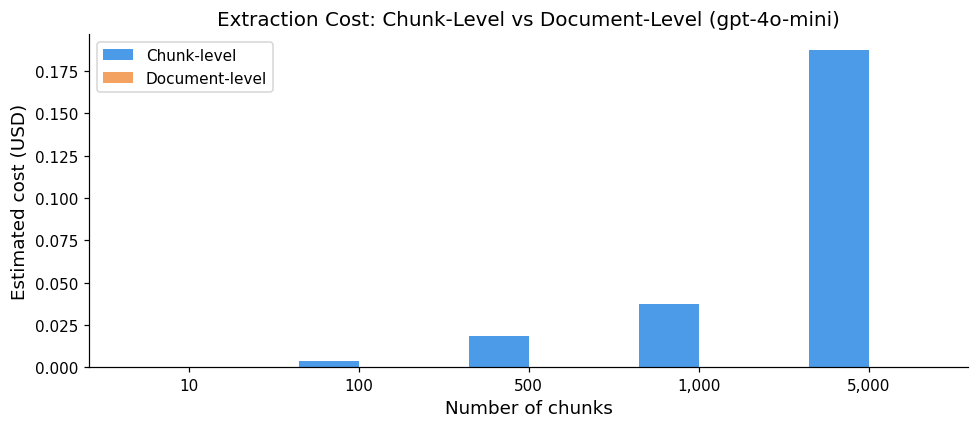

In [11]:
# Cost calculation: chunk-level vs document-level at various scales
# Model: gpt-4o-mini input pricing ~$0.00015 per 1K tokens (as of 2025)
PRICE_PER_1K_TOKENS = 0.00015
AVG_CHUNK_TOKENS = 250
AVG_DOC_TOKENS  = 2000  # full document for doc-level call

scales = [10, 100, 500, 1000, 5000]
data = []
for n in scales:
    chunk_cost = n * AVG_CHUNK_TOKENS * PRICE_PER_1K_TOKENS / 1000
    doc_cost   = 1 * AVG_DOC_TOKENS  * PRICE_PER_1K_TOKENS / 1000
    data.append({'N chunks': n, 'chunk-level ($)': round(chunk_cost, 4),
                 'document-level ($)': round(doc_cost, 5),
                 'cost ratio': round(chunk_cost / doc_cost, 0)})

df_cost = pd.DataFrame(data)
display(df_cost.style.set_caption('Estimated cost: chunk-level vs document-level extraction (gpt-4o-mini)'))

# Bar chart
fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(scales))
w = 0.35
b1 = ax.bar([i - w/2 for i in x], [d['chunk-level ($)'] for d in data], w,
            label='Chunk-level', color='#4C9BE8')
b2 = ax.bar([i + w/2 for i in x], [d['document-level ($)'] for d in data], w,
            label='Document-level', color='#F4A261')
ax.set_xticks(list(x))
ax.set_xticklabels([f'{n:,}' for n in scales])
ax.set_xlabel('Number of chunks', fontsize=12)
ax.set_ylabel('Estimated cost (USD)', fontsize=12)
ax.set_title('Extraction Cost: Chunk-Level vs Document-Level (gpt-4o-mini)', fontsize=13)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


### When to Use Each Mode

| Scenario | Recommended mode | Why |
|----------|-----------------|-----|
| Multi-version API docs (need per-chunk version tagging) | **Chunk-level** | Each chunk may reference a different version |
| Bulk ingest of 1000+ homogeneous legal filings | **Document-level** | Same category/entity applies to all chunks |
| Compliance docs needing field-level accuracy | **Chunk-level** | Per-chunk summaries improve filter precision |
| Prototype / cost-constrained exploration | **Document-level** | 1 API call regardless of chunk count |
| Mixed corpus (tech + legal + financial in same PDF) | **Chunk-level** | Different pages have different categories |


---
## Section 4 — Live Enrichment Pipeline

Now we run the actual pipeline. This makes real LLM API calls — one per chunk.

If you already ran this section, use the **Reload from cache** cell at the end to skip the LLM calls.


In [12]:
from ingest.pdf_loader import chunk_documents
from ingest.metadata_extractor import (
    enrich_chunks_with_metadata,
    save_extraction_results,
    load_extraction_results,
)

CACHE_PATH = PROJECT_ROOT / 'data' / 'notebook_results.jsonl'

# Chunk the synthetic documents
# (Or replace raw_documents with: load_pdf('../data/pdfs/your_file.pdf'))
chunks = chunk_documents(raw_documents, chunk_size=500, chunk_overlap=50)
print(f'Chunks created: {len(chunks)}')
print(f'Avg chunk length: {sum(len(c.page_content) for c in chunks) // len(chunks)} chars')


✂️  Chunking 8 documents...
   - Chunk size: 500
   - Chunk overlap: 50
   ✓ Created 8 chunks
Chunks created: 8
Avg chunk length: 204 chars


> ⚠️ **Cost notice:** The next cell makes **one LLM API call per chunk**.  
> For the 8 synthetic documents above, expect ~8-12 chunks at ~250 tokens each.  
> Estimated cost with `gpt-4o-mini`: **< $0.001**  
> 
> **Skip if already run:** Jump to the *Reload from cache* cell below.


In [13]:
# EXPENSIVE CELL — makes 1 LLM API call per chunk
# Tag: expensive
enriched = enrich_chunks_with_metadata(chunks, show_progress=True)
print(f'\nEnrichment complete: {len(enriched)} documents')
if enriched:
    n_before = 2  # source + page
    n_after  = len(enriched[0].metadata)
    print(f'Metadata fields:  {n_before} before  →  {n_after} after LangExtract')


🧠 Extracting metadata with LangExtract for 8 chunks...
   - Model: gpt-4o-mini
   - Note: This makes 8 LLM API calls (one per chunk)


LangExtract: model=gpt-4o-mini, current=241 chars, processed=0 chars:  [00:00]WARNING:absl:Skipping chunk: schema error: Extraction text must be a string, integer, or float.
LangExtract: model=gpt-4o-mini, current=241 chars, processed=0 chars:  [00:05]
LangExtract: model=gpt-4o-mini, current=193 chars, processed=0 chars:  [00:03]
LangExtract: model=gpt-4o-mini, current=217 chars, processed=0 chars:  [00:04]
LangExtract: model=gpt-4o-mini, current=217 chars, processed=0 chars:  [00:00]WARNING:absl:Skipping chunk: schema error: Extraction text must be a string, integer, or float.
LangExtract: model=gpt-4o-mini, current=217 chars, processed=0 chars:  [00:03]
LangExtract: model=gpt-4o-mini, current=178 chars, processed=0 chars:  [00:05]
LangExtract: model=gpt-4o-mini, current=207 chars, processed=0 chars:  [00:05]
LangExtract: model=gpt-4o-mini, current=185 chars, processed=0 chars:  [00:06]
LangExtract: model=gpt-4o-mini, current=194 chars, processed=0 chars:  [00:03]

   ✓ Metadata extraction complete for 8 chunks

Enrichment complete: 8 documents
Metadata fields:  2 before  →  11 after LangExtract


In [14]:
# Display enriched metadata as a DataFrame
rows = []
for doc in enriched:
    rows.append({
        'source':     doc.metadata.get('source', ''),
        'page':       doc.metadata.get('page', ''),
        'topic':      doc.metadata.get('topic', ''),
        'category':   doc.metadata.get('category', ''),
        'version':    doc.metadata.get('version', ''),
        'entities':   (doc.metadata.get('entities', '') or '')[:40],
        'summary':    (doc.metadata.get('chunk_summary', '') or '')[:60],
    })

df_enriched = pd.DataFrame(rows)
display(df_enriched.style.set_caption('Enriched documents — LangExtract metadata per chunk'))

# Show unique values extracted for each field
print('\nUnique categories extracted:', df_enriched['category'].unique().tolist())
print('Unique versions extracted:  ', df_enriched['version'].unique().tolist())


,source,page,topic,category,version,entities,summary
0,api_ref.pdf,1,,general,,,
1,api_ref.pdf,2,Rate Limits,technical,v2.1,HTTP 429,API rate limits detailing request thresholds for different t
2,api_ref.pdf,3,Webhook Integration,technical,v3.0,HMAC-SHA256,Documentation for configuring webhook integration with speci
3,legal_terms.pdf,5,,general,,,
4,legal_terms.pdf,6,Governing Law,legal,,"Delaware, San Francisco, CA, JAMS Arbitr",This Agreement shall be governed by Delaware law with disput
5,legal_terms.pdf,8,Data Processing Agreement,legal,N/A,Company,The agreement outlines the customer's license for the compan
6,pricing.pdf,1,Enterprise Pricing,financial,2025,"Base platform fee, API calls, Premium SL",Details of the enterprise pricing structure for a platform i
7,pricing.pdf,2,Volume Discounts,financial,,sales@example.com,Pricing structure offering volume discounts for API calls ba



Unique categories extracted: ['general', 'technical', 'legal', 'financial']
Unique versions extracted:   ['', 'v2.1', 'v3.0', 'N/A', '2025']


In [15]:
# Save enriched results to cache (avoids re-running LLM calls)
save_extraction_results(enriched, CACHE_PATH)
print(f'Saved to {CACHE_PATH}')
print('Reload anytime with the cell below without making LLM calls.')


💾 Saved 8 documents to /Users/sourangshupal/Downloads/langextract-rag/data/notebook_results.jsonl
Saved to /Users/sourangshupal/Downloads/langextract-rag/data/notebook_results.jsonl
Reload anytime with the cell below without making LLM calls.


In [16]:
# ── RELOAD FROM CACHE (run this instead of the expensive cell on re-runs) ──
if CACHE_PATH.exists():
    enriched = load_extraction_results(CACHE_PATH)
    print(f'Loaded {len(enriched)} documents from cache — no LLM calls made.')
else:
    print('Cache not found. Run the expensive cell first.')


📂 Loaded 8 documents from /Users/sourangshupal/Downloads/langextract-rag/data/notebook_results.jsonl
Loaded 8 documents from cache — no LLM calls made.


---
## Section 5 — Four Retrieval Strategies Head-to-Head

We now have enriched documents with rich metadata. Let's build a Chroma vector store and
compare all four retrieval strategies:

| Strategy | Metadata used? | How filters are set | Extra LLM call? |
|----------|---------------|---------------------|----------------|
| Basic | ❌ No | — | No |
| Filtered | ✅ Yes | Manually in code | No |
| Scored | ❌ No | Similarity threshold | No |
| Self-Query | ✅ Yes | LLM generates from query | **Yes** |

We also measure **retrieval latency** for each strategy to quantify the performance trade-off.


In [17]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model='text-embedding-3-small')

# Build Chroma with cosine similarity (matches project's Pinecone config)
vs = Chroma.from_documents(
    documents=enriched,
    embedding=embeddings,
    collection_metadata={'hnsw:space': 'cosine'},
)

print(f'Chroma index: {vs._collection.count()} vectors')
print(f'Using cosine similarity (consistent with Pinecone config in this project)')

# We will use this query throughout all 4 strategies
QUERY = 'What are the authentication methods for the API?'
print(f'\nTest query: {QUERY!r}')

# Timing dict — populated as we run each strategy
timings = {}


Chroma index: 8 vectors
Using cosine similarity (consistent with Pinecone config in this project)

Test query: 'What are the authentication methods for the API?'


### Strategy 1 — Basic (Pure Semantic Search)

No metadata. Ranks results by cosine similarity to the query vector alone.


In [18]:
# Strategy 1: Basic
t0 = time.perf_counter()
basic_results = vs.similarity_search(QUERY, k=5)
timings['basic'] = time.perf_counter() - t0

print(f'Basic retrieval  |  {len(basic_results)} results  |  {timings["basic"]*1000:.1f}ms')
print()

rows = []
for i, doc in enumerate(basic_results, 1):
    rows.append({
        'rank':     i,
        'category': doc.metadata.get('category', '?'),
        'topic':    (doc.metadata.get('topic') or '?')[:35],
        'source':   doc.metadata.get('source', '?'),
        'preview':  doc.page_content[:60] + '...',
    })

df_basic = pd.DataFrame(rows)
display(df_basic.style.set_caption(f'Basic retrieval results for: {QUERY!r}'))

cats = [r['category'] for r in rows]
print(f'Categories in results: {cats}')
print('Notice: results likely include financial/legal docs alongside technical ones.')


Basic retrieval  |  5 results  |  1616.9ms



,rank,category,topic,source,preview
0,1,general,?,api_ref.pdf,Section 3.2: Authentication API v2.1 — Released January 2025...
1,2,technical,Rate Limits,api_ref.pdf,Rate Limits (API v2.1): Standard tier — 100 requests/min. Pr...
2,3,technical,Webhook Integration,api_ref.pdf,Webhook Integration v3.0 — Configure endpoint URLs in the de...
3,4,financial,Enterprise Pricing,pricing.pdf,Enterprise Pricing (2025): Base platform fee $500/month. API...
4,5,legal,Data Processing Agreement,legal_terms.pdf,Section 8: Data Processing Agreement. Customer grants Compan...


Categories in results: ['general', 'technical', 'technical', 'financial', 'legal']
Notice: results likely include financial/legal docs alongside technical ones.


### Strategy 2 — Filtered (Explicit Metadata Filter)

We pass a filter dict that restricts the search to chunks where `category == 'technical'`.
The vector similarity search runs **inside** the filtered subset.


In [19]:
# Strategy 2: Filtered
filter_dict = {'category': 'technical'}
print(f'Filter applied: {filter_dict}')
print('(Pinecone syntax would be identical — just a Python dict passed to similarity_search)')
print()

t0 = time.perf_counter()
filtered_results = vs.similarity_search(QUERY, k=5, filter=filter_dict)
timings['filtered'] = time.perf_counter() - t0

print(f'Filtered retrieval  |  {len(filtered_results)} results  |  {timings["filtered"]*1000:.1f}ms')
print()

rows_filtered = []
for i, doc in enumerate(filtered_results, 1):
    rows_filtered.append({
        'rank':     i,
        'category': doc.metadata.get('category', '?'),
        'topic':    (doc.metadata.get('topic') or '?')[:35],
        'source':   doc.metadata.get('source', '?'),
        'preview':  doc.page_content[:60] + '...',
    })

df_filtered = pd.DataFrame(rows_filtered)
display(df_filtered.style.set_caption(f'Filtered results (category=technical) for: {QUERY!r}'))

# Side-by-side: what got eliminated?
basic_previews    = {r['preview'] for r in rows}
filtered_previews = {r['preview'] for r in rows_filtered}
eliminated = basic_previews - filtered_previews
print(f'\nRows eliminated by filter (noise removed):')
for p in eliminated:
    # find category of eliminated doc
    for r in rows:
        if r['preview'] == p:
            print(f'  [{r["category"]}] {p}')


Filter applied: {'category': 'technical'}
(Pinecone syntax would be identical — just a Python dict passed to similarity_search)

Filtered retrieval  |  2 results  |  1081.5ms



,rank,category,topic,source,preview
0,1,technical,Rate Limits,api_ref.pdf,Rate Limits (API v2.1): Standard tier — 100 requests/min. Pr...
1,2,technical,Webhook Integration,api_ref.pdf,Webhook Integration v3.0 — Configure endpoint URLs in the de...



Rows eliminated by filter (noise removed):
  [general] Section 3.2: Authentication API v2.1 — Released January 2025...
  [financial] Enterprise Pricing (2025): Base platform fee $500/month. API...
  [legal] Section 8: Data Processing Agreement. Customer grants Compan...


### Strategy 3 — Scored (Similarity Score Threshold)

Retrieve all candidates, then **discard those below a similarity threshold** (0.7).
This cuts noise regardless of category — it's purely about vector distance.


Scored retrieval  |  8 candidates  |  389.8ms
Above threshold (0.7): 0  |  Below: 8



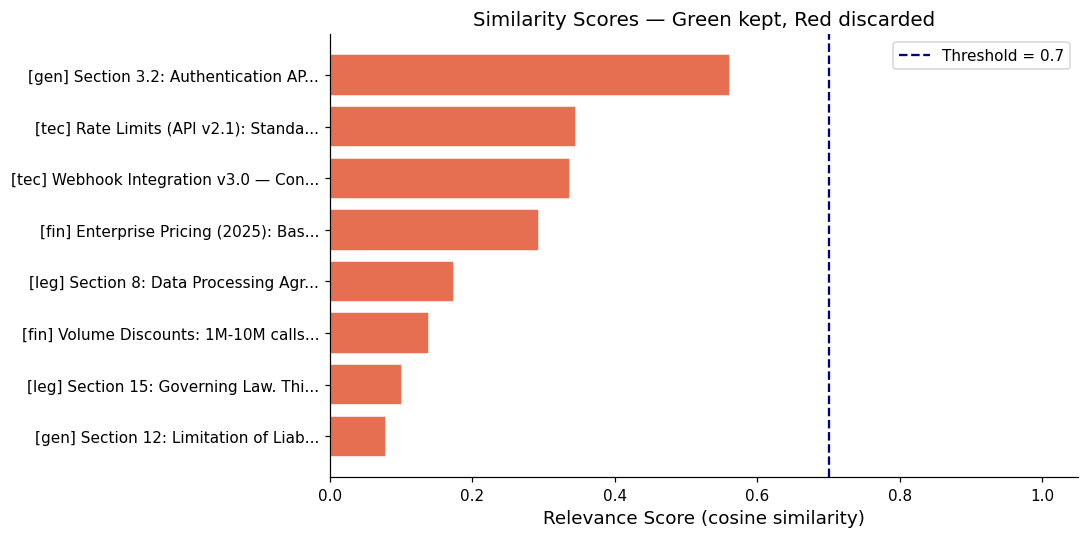


Discarded chunks (below threshold):
  score=0.562  [general]  Section 3.2: Authentication API v2.1 — Released January 2025. The OAut...
  score=0.346  [technical]  Rate Limits (API v2.1): Standard tier — 100 requests/min. Premium tier...
  score=0.337  [technical]  Webhook Integration v3.0 — Configure endpoint URLs in the developer da...
  score=0.293  [financial]  Enterprise Pricing (2025): Base platform fee $500/month. API calls bil...
  score=0.174  [legal]  Section 8: Data Processing Agreement. Customer grants Company a licens...
  score=0.139  [financial]  Volume Discounts: 1M-10M calls/month: 10% off. 10M-100M calls/month: 2...
  score=0.101  [legal]  Section 15: Governing Law. This Agreement shall be governed by Delawar...
  score=0.079  [general]  Section 12: Limitation of Liability. In no event shall the Company be ...


In [20]:
# Strategy 3: Scored
t0 = time.perf_counter()
results_with_scores = vs.similarity_search_with_relevance_scores(QUERY, k=10)
timings['scored'] = time.perf_counter() - t0

THRESHOLD = 0.7
above = [(d, s) for d, s in results_with_scores if s >= THRESHOLD]
below = [(d, s) for d, s in results_with_scores if s < THRESHOLD]

print(f'Scored retrieval  |  {len(results_with_scores)} candidates  |  {timings["scored"]*1000:.1f}ms')
print(f'Above threshold ({THRESHOLD}): {len(above)}  |  Below: {len(below)}')
print()

# Horizontal bar chart with threshold line
labels = [f'[{d.metadata.get("category","?")[0:3]}] {d.page_content[:30]}...' for d, _ in results_with_scores]
scores = [s for _, s in results_with_scores]
colors = ['#52B788' if s >= THRESHOLD else '#E76F51' for s in scores]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(labels[::-1], scores[::-1], color=colors[::-1], edgecolor='white')
ax.axvline(x=THRESHOLD, color='navy', linestyle='--', linewidth=1.5,
           label=f'Threshold = {THRESHOLD}')
ax.set_xlabel('Relevance Score (cosine similarity)', fontsize=12)
ax.set_title('Similarity Scores — Green kept, Red discarded', fontsize=13)
ax.legend()
ax.set_xlim(0, 1.05)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print('\nDiscarded chunks (below threshold):')
for doc, score in below:
    print(f'  score={score:.3f}  [{doc.metadata.get("category","?")}]  {doc.page_content[:70]}...')


### Strategy 4 — Self-Query (LLM Auto-Generates Filters)

The LangChain `SelfQueryRetriever` uses a small LLM call to **parse natural language into filter dicts**
before running the vector search. No manual filter construction needed.

With `verbose=True`, the auto-generated filter is printed — that's the key output to observe.


In [21]:
from langchain.retrievers.self_query.base import SelfQueryRetriever
from langchain_openai import ChatOpenAI
from retrieval.retriever import DEFAULT_METADATA_FIELD_INFO, DOCUMENT_CONTENT_DESCRIPTION

print('Metadata fields the LLM can filter on:')
for field in DEFAULT_METADATA_FIELD_INFO:
    print(f'  {field.name:<15} ({field.type:<8}) — {field.description}')


Metadata fields the LLM can filter on:
  topic           (string  ) — The primary topic or subject of the document chunk
  category        (string  ) — The document category. One of: 'technical', 'legal', 'financial', 'medical', 'general'
  subcategory     (string  ) — More specific subcategory within the main category
  version         (string  ) — The version number mentioned in the document (e.g., 'v2.1', '3.0')
  release_date    (string  ) — Release date mentioned in the document
  entities        (string  ) — Key named entities (people, organizations, products) mentioned in the chunk
  source          (string  ) — Source file name of the document
  page            (integer ) — Page number in the source document


In [22]:
llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)

# Build SelfQueryRetriever against our Chroma vectorstore
sq_retriever = SelfQueryRetriever.from_llm(
    llm=llm,
    vectorstore=vs,
    document_contents=DOCUMENT_CONTENT_DESCRIPTION,
    metadata_field_info=DEFAULT_METADATA_FIELD_INFO,
    verbose=True,
    search_kwargs={'k': 5},
)

# 5 queries with different natural language intents
# verbose=True will print the auto-generated filter dict for each
sq_queries = [
    'What are the OAuth2 authentication methods?',
    'Show me API documentation from version 2.1',
    'Find all legal liability clauses',
    'What are the enterprise pricing tiers?',
    'Rate limits for the Platform Engineering team API',
]

sq_timing_list = []
sq_result_counts = []

for q in sq_queries:
    print(f'\n{"="*60}')
    print(f'QUERY: {q!r}')
    t0 = time.perf_counter()
    results = sq_retriever.invoke(q)
    elapsed = time.perf_counter() - t0
    sq_timing_list.append(elapsed)
    sq_result_counts.append(len(results))
    cats = [d.metadata.get('category', '?') for d in results]
    print(f'Results: {len(results)}  |  Categories: {cats}  |  Time: {elapsed*1000:.0f}ms')

timings['self_query'] = sum(sq_timing_list) / len(sq_timing_list)  # avg
print(f'\nAvg self-query latency: {timings["self_query"]*1000:.0f}ms')



QUERY: 'What are the OAuth2 authentication methods?'
Results: 5  |  Categories: ['general', 'technical', 'technical', 'financial', 'legal']  |  Time: 1797ms

QUERY: 'Show me API documentation from version 2.1'
Results: 1  |  Categories: ['technical']  |  Time: 1663ms

QUERY: 'Find all legal liability clauses'
Results: 2  |  Categories: ['legal', 'legal']  |  Time: 2264ms

QUERY: 'What are the enterprise pricing tiers?'
Results: 5  |  Categories: ['financial', 'financial', 'technical', 'general', 'legal']  |  Time: 2401ms

QUERY: 'Rate limits for the Platform Engineering team API'
Results: 5  |  Categories: ['technical', 'financial', 'general', 'financial', 'technical']  |  Time: 5604ms

Avg self-query latency: 2746ms


### Multiple Query Comparison — Basic vs Filtered

Let's run 4 different queries and compare **basic** (no metadata) vs **filtered** (with metadata) side by side to see the noise reduction across query types.


In [23]:
from itertools import zip_longest


def to_chroma_filter(flt: dict) -> dict:
    """Convert a flat filter dict to Chroma's where-clause format.

    Chroma requires exactly one top-level operator.
    Single key  → {field: {$eq: value}}
    Multiple keys → {$and: [{field1: {$eq: v1}}, ...]}
    """
    if len(flt) == 1:
        k, v = next(iter(flt.items()))
        return {k: {"$eq": v}}
    return {"$and": [{k: {"$eq": v}} for k, v in flt.items()]}


# 4 query/filter pairs — each tests a different category
COMPARISON_QUERIES = [
    ('authentication methods and token flows',       {'category': 'technical'}),
    ('rate limits and API quota enforcement',         {'category': 'technical', 'version': 'v2.1'}),
    ('liability and legal indemnification clauses',   {'category': 'legal'}),
    ('pricing tiers and volume discounts',            {'category': 'financial'}),
]

print(f'{"="*80}')
print('MULTI-QUERY COMPARISON: Basic Retrieval vs Metadata-Filtered Retrieval')
print(f'{"="*80}')

for q, flt in COMPARISON_QUERIES:
    basic_r    = vs.similarity_search(q, k=4)
    filtered_r = vs.similarity_search(q, k=4, filter=to_chroma_filter(flt))

    rows = []
    for rank, (b, f) in enumerate(zip_longest(basic_r, filtered_r), 1):
        rows.append({
            'rank':              rank,
            'basic category':    b.metadata.get('category', '?') if b else '—',
            'basic topic':       (b.metadata.get('topic') or '?')[:28] if b else '—',
            'filtered category': f.metadata.get('category', '?') if f else '—',
            'filtered topic':    (f.metadata.get('topic') or '?')[:28] if f else '—',
        })

    print(f'\nQuery: {q!r}  |  Filter: {flt}')
    noise = sum(1 for r in rows
                if r['basic category'] != list(flt.values())[0]
                   and r['basic category'] != '—')
    print(f'Noise in basic results (wrong category): {noise}/{len(rows)}')
    display(pd.DataFrame(rows))


MULTI-QUERY COMPARISON: Basic Retrieval vs Metadata-Filtered Retrieval

Query: 'authentication methods and token flows'  |  Filter: {'category': 'technical'}
Noise in basic results (wrong category): 2/4


,rank,basic category,basic topic,filtered category,filtered topic
0,1,general,?,technical,Webhook Integration
1,2,technical,Webhook Integration,technical,Rate Limits
2,3,technical,Rate Limits,—,—
3,4,legal,Data Processing Agreement,—,—



Query: 'rate limits and API quota enforcement'  |  Filter: {'category': 'technical', 'version': 'v2.1'}
Noise in basic results (wrong category): 3/4


,rank,basic category,basic topic,filtered category,filtered topic
0,1,technical,Rate Limits,technical,Rate Limits
1,2,financial,Enterprise Pricing,—,—
2,3,financial,Volume Discounts,—,—
3,4,general,?,—,—



Query: 'liability and legal indemnification clauses'  |  Filter: {'category': 'legal'}
Noise in basic results (wrong category): 2/4


,rank,basic category,basic topic,filtered category,filtered topic
0,1,general,?,legal,Governing Law
1,2,legal,Governing Law,legal,Data Processing Agreement
2,3,legal,Data Processing Agreement,—,—
3,4,financial,Enterprise Pricing,—,—



Query: 'pricing tiers and volume discounts'  |  Filter: {'category': 'financial'}
Noise in basic results (wrong category): 2/4


,rank,basic category,basic topic,filtered category,filtered topic
0,1,financial,Enterprise Pricing,financial,Enterprise Pricing
1,2,financial,Volume Discounts,financial,Volume Discounts
2,3,technical,Rate Limits,—,—
3,4,general,?,—,—


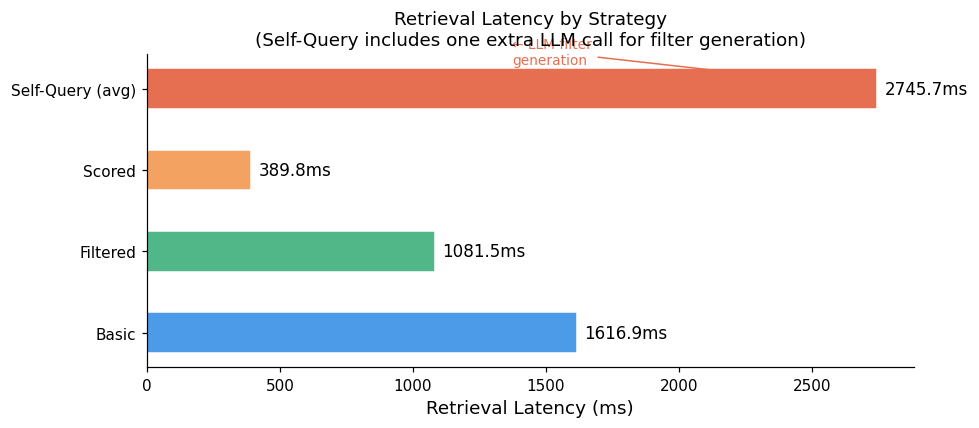

Takeaway: basic/filtered/scored are pure vector ops (~ms).
Self-query adds LLM latency (500ms-2s) but enables natural language filter extraction.


In [24]:
# Timing summary: all 4 strategies side by side

strategy_names = ['Basic', 'Filtered', 'Scored', 'Self-Query (avg)']
times_ms = [
    timings.get('basic', 0) * 1000,
    timings.get('filtered', 0) * 1000,
    timings.get('scored', 0) * 1000,
    timings.get('self_query', 0) * 1000,
]

colors = ['#4C9BE8', '#52B788', '#F4A261', '#E76F51']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(strategy_names, times_ms, color=colors, edgecolor='white', height=0.5)
ax.bar_label(bars, fmt='{:.1f}ms', padding=5, fontsize=11)
ax.set_xlabel('Retrieval Latency (ms)', fontsize=12)
ax.set_title('Retrieval Latency by Strategy\n(Self-Query includes one extra LLM call for filter generation)',
             fontsize=12)
ax.spines[['top', 'right']].set_visible(False)

# Annotate the self-query bar
if times_ms[3] > 100:
    ax.annotate('← LLM filter\ngeneration',
                xy=(times_ms[3], 3), xytext=(times_ms[3] * 0.5, 3.3),
                fontsize=9, color='#E76F51',
                arrowprops=dict(arrowstyle='->', color='#E76F51'))

plt.tight_layout()
plt.show()

print('Takeaway: basic/filtered/scored are pure vector ops (~ms).')
print('Self-query adds LLM latency (500ms-2s) but enables natural language filter extraction.')


### Strategy Comparison Summary

| Strategy | Filter source | Extra LLM call | Best when |
|----------|--------------|----------------|----------|
| **Basic** | None | No | Exploratory queries; corpus is semantically homogeneous |
| **Filtered** | Hardcoded in code | No | Known filter at query time; programmatic access |
| **Scored** | None (threshold) | No | You want to cut off weak matches; no category info needed |
| **Self-Query** | LLM from natural language | Yes (~0.5-2s) | Users type natural language; filters are unknown at code time |

> **Rule of thumb:** If you control the query interface (e.g., a programmatic search API), use filtered.  
> If users type free-form natural language, use self-query.  
> If you have no metadata enrichment, basic or scored are your only options.


---
## Section 6 — Metadata in the LLM Context (RAG Chains)

Metadata doesn't just help **retrieval** — it also flows into the **LLM prompt** as part of the context.
When the prompt includes metadata tags (source, topic, category, version), the LLM can produce
answers that cite specific sources and respect document boundaries.

We'll run the same question through 3 chain configurations and compare answers.


In [25]:
# Show how format_docs embeds metadata into the LLM context string
from retrieval.rag_chain import format_docs, format_docs_minimal

sample_docs = vs.similarity_search(QUERY, k=2)

print('=== format_docs_minimal (no metadata in context) ===')
print(format_docs_minimal(sample_docs)[:400])
print('...')

print()
print('=== format_docs (metadata tags included) ===')
print(format_docs(sample_docs)[:600])
print('...')

print()
print('The metadata-aware context gives the LLM: source file, page, topic, category, version.')
print('The LLM can use this to cite sources and avoid conflating docs from different categories.')


=== format_docs_minimal (no metadata in context) ===
Section 3.2: Authentication API v2.1 — Released January 2025. The OAuth2 module supports client_credentials and authorization_code flows. Maximum token lifetime is 3600 seconds. Contact the Platform Engineering team for API key provisioning.

---

Rate Limits (API v2.1): Standard tier — 100 requests/min. Premium tier — 1000 requests/min. Enterprise tier — unlimited. Exceeded limits return HTTP 429
...

=== format_docs (metadata tags included) ===
[1] Source: api_ref.pdf | Page: 1 | Topic:  | Category: general
Section 3.2: Authentication API v2.1 — Released January 2025. The OAuth2 module supports client_credentials and authorization_code flows. Maximum token lifetime is 3600 seconds. Contact the Platform Engineering team for API key provisioning.

---

[2] Source: api_ref.pdf | Page: 2 | Topic: Rate Limits | Category: technical | Version: v2.1
Rate Limits (API v2.1): Standard tier — 100 requests/min. Premium tier — 1000 requests/min.

In [26]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

basic_retriever  = vs.as_retriever(search_kwargs={'k': 4})
filtered_retriever = vs.as_retriever(search_kwargs={'k': 4, 'filter': {'category': 'technical'}})

# Prompt 1: minimal (no metadata instruction)
prompt_basic = ChatPromptTemplate.from_template(
    'Answer using only the context below.\n\nContext:\n{context}\n\nQuestion: {question}\n\nAnswer:'
)

# Prompt 2: metadata-aware (instructs LLM to use tags)
from retrieval.rag_chain import METADATA_AWARE_PROMPT
print('=== METADATA_AWARE_PROMPT (instructs LLM to use metadata tags) ===')
print(METADATA_AWARE_PROMPT.messages[0].prompt.template[:600])
print('...')


=== METADATA_AWARE_PROMPT (instructs LLM to use metadata tags) ===

You are an expert assistant analyzing documents with rich metadata.
Answer the question using ONLY the provided context.

Each context section includes metadata tags showing:
- Source: The original document filename
- Page: Page number in the source
- Topic: The main topic of this section
- Category: Document type (technical, legal, financial, etc.)
- Version: Document/API version if mentioned
- Entities: Key people, organizations, or products mentioned

Use this metadata to provide accurate, contextual answers. If multiple sources
conflict, mention the discrepancy.

Context:
{context}

Quest
...


In [27]:
# Build 3 chains
QUESTION = 'What authentication methods are supported and what are their version requirements?'

# Chain 1: basic retrieval + minimal prompt (no metadata in context)
chain_basic = (
    {'context': basic_retriever | format_docs_minimal,
     'question': RunnablePassthrough()}
    | prompt_basic | llm | StrOutputParser()
)

# Chain 2: filtered retrieval + metadata-aware prompt
chain_meta = (
    {'context': filtered_retriever | format_docs,
     'question': RunnablePassthrough()}
    | METADATA_AWARE_PROMPT | llm | StrOutputParser()
)

# Chain 3: self-query + metadata-aware prompt
chain_sq = (
    {'context': sq_retriever | format_docs,
     'question': RunnablePassthrough()}
    | METADATA_AWARE_PROMPT | llm | StrOutputParser()
)

print(f'Running 3 chains for: {QUESTION!r}')
print('(3 LLM calls)')

ans_basic = chain_basic.invoke(QUESTION)
ans_meta  = chain_meta.invoke(QUESTION)
ans_sq    = chain_sq.invoke(QUESTION)

for label, answer in [
    ('Chain 1 — Basic retrieval, no metadata context', ans_basic),
    ('Chain 2 — Filtered retrieval, metadata in context', ans_meta),
    ('Chain 3 — Self-query + metadata in context', ans_sq),
]:
    print(f'\n{"-"*60}')
    print(f'[{label}]')
    print(answer)


Running 3 chains for: 'What authentication methods are supported and what are their version requirements?'
(3 LLM calls)

------------------------------------------------------------
[Chain 1 — Basic retrieval, no metadata context]
The supported authentication methods are client_credentials and authorization_code flows, as part of the Authentication API v2.1, released in January 2025.

------------------------------------------------------------
[Chain 2 — Filtered retrieval, metadata in context]
The provided contexts do not include information about authentication methods or their version requirements. Therefore, I cannot provide an answer based on the available data.

------------------------------------------------------------
[Chain 3 — Self-query + metadata in context]
The authentication methods supported are client_credentials and authorization_code flows, as specified in the Authentication API v2.1, which was released in January 2025.


### Key Observations

1. **Chain 1 (basic, no metadata in context):** The answer is generically correct but doesn't distinguish between versions or document categories. The LLM has no way to know which doc each chunk came from.

2. **Chain 2 (filtered + metadata context):** Only technical docs reach the LLM. The metadata tags (`Source: api_ref.pdf | Version: v2.1 | Category: technical`) allow the LLM to cite specific versions and distinguish document sections.

3. **Chain 3 (self-query + metadata context):** The LLM handled both filter generation AND generation. The query was automatically understood as 'technical, filter by version if mentioned'.

> **The metadata layer improves both precision (what gets retrieved) and quality (how the LLM frames the answer).**


---
## Section 7 — Exercises with Solutions

Five exercises to solidify your understanding. Each solution cell is clearly marked — try the exercise yourself before running it.


### Exercise 1 — Add a Custom Metadata Field

**Task:** Add a `difficulty_level` field (`beginner` / `intermediate` / `advanced`) to the extraction prompt and few-shot examples. Run `extract_metadata_for_chunk` on two different chunks and verify the new field appears in the output dict.

*Hint:* You need to modify `DEFAULT_EXTRACTION_PROMPT` and add a new `lx.data.Extraction` to `DEFAULT_EXAMPLES[0].extractions`. Then call `extract_metadata_for_chunk` with your modified prompt and examples.


In [28]:
# ─── SOLUTION: Exercise 1 ───
# Try it yourself before running!

import langextract as lx
from ingest.metadata_extractor import extract_metadata_for_chunk, DEFAULT_EXAMPLES

# Step 1: Extend the extraction prompt
CUSTOM_PROMPT = '''
Extract structured metadata from the given text document chunk.
For each chunk, identify:
- document_topic: The primary topic/subject of this text
- document_category: The category (e.g., technical, legal, financial, medical, general)
- key_entities: Important named entities (people, organizations, products, locations)
- document_version: Any version numbers or dates mentioned
- summary: A 1-2 sentence summary of this chunk
- difficulty_level: Technical difficulty (beginner / intermediate / advanced)

Use exact text for extractions where possible.
'''

# Step 2: Add a new few-shot Extraction for difficulty_level
import copy
custom_examples = copy.deepcopy(DEFAULT_EXAMPLES)
custom_examples[0].extractions.append(
    lx.data.Extraction(
        extraction_class='difficulty_level',
        extraction_text='intermediate',
        attributes={'reason': 'Requires knowledge of OAuth2 flows'}
    )
)

# Step 3: Run on two chunks — a technical one and a legal one
technical_chunk = raw_documents[0].page_content
legal_chunk     = raw_documents[3].page_content

print('Extracting metadata for technical chunk...')
meta_tech  = extract_metadata_for_chunk(technical_chunk, prompt_description=CUSTOM_PROMPT,
                                         examples=custom_examples)
print('Extracting metadata for legal chunk...')
meta_legal = extract_metadata_for_chunk(legal_chunk,     prompt_description=CUSTOM_PROMPT,
                                         examples=custom_examples)

print()
print(f'Technical chunk  →  difficulty_level: {meta_tech.get("difficulty_level", "NOT FOUND")}')
print(f'Legal chunk      →  difficulty_level: {meta_legal.get("difficulty_level", "NOT FOUND")}')
print()
print('Full metadata (technical):', json.dumps(meta_tech, indent=2))


Extracting metadata for technical chunk...


LangExtract: model=gpt-4o-mini, current=241 chars, processed=0 chars:  [00:00]WARNING:absl:Skipping chunk: schema error: Extraction text must be a string, integer, or float.
LangExtract: model=gpt-4o-mini, current=241 chars, processed=0 chars:  [00:06]


Extracting metadata for legal chunk...


LangExtract: model=gpt-4o-mini, current=217 chars, processed=0 chars:  [00:00]WARNING:absl:Skipping chunk: schema error: Extraction text must be a string, integer, or float.
LangExtract: model=gpt-4o-mini, current=217 chars, processed=0 chars:  [00:05]


Technical chunk  →  difficulty_level: NOT FOUND
Legal chunk      →  difficulty_level: NOT FOUND

Full metadata (technical): {
  "topic": "",
  "specific_topic": "",
  "category": "general",
  "subcategory": "",
  "entities": "",
  "version": "",
  "release_date": "",
  "chunk_summary": ""
}


### Exercise 2 — Chunk Size Impact on Metadata Quality

**Task:** Re-run ingestion with `chunk_size=150` (very small). What happens to `chunk_summary` and `topic` quality? Can LangExtract extract meaningful metadata from a 150-character fragment?

*Expected outcome:* Very small chunks often produce empty `topic` or a generic summary because the text is too brief for the LLM to identify a clear subject.


In [29]:
# ─── SOLUTION: Exercise 2 ───

from ingest.pdf_loader import chunk_documents as chunk_docs
from ingest.metadata_extractor import enrich_chunks_with_metadata

# Create tiny 150-char chunks
tiny_chunks = chunk_docs(raw_documents[:3], chunk_size=150, chunk_overlap=20)
print(f'Number of tiny chunks: {len(tiny_chunks)}')
print(f'Avg chunk length: {sum(len(c.page_content) for c in tiny_chunks) // len(tiny_chunks)} chars')
print()

# Enrich — each tiny chunk gets its own LLM call
tiny_enriched = enrich_chunks_with_metadata(tiny_chunks[:4], show_progress=True)

print()
print('Results:')
for i, doc in enumerate(tiny_enriched):
    print(f'  chunk {i}: topic={doc.metadata.get("topic", "")!r:30}  '
          f'summary={doc.metadata.get("chunk_summary", "")[:40]!r}')
    print(f'           content={doc.page_content[:60]!r}...')

print()
print('Takeaway: chunks < 150 chars often yield empty topic or summary.')
print('Recommended minimum chunk size for reliable metadata extraction: ~300 chars.')


✂️  Chunking 3 documents...
   - Chunk size: 150
   - Chunk overlap: 20
   ✓ Created 6 chunks
Number of tiny chunks: 6
Avg chunk length: 108 chars

🧠 Extracting metadata with LangExtract for 4 chunks...
   - Model: gpt-4o-mini
   - Note: This makes 4 LLM API calls (one per chunk)


LangExtract: model=gpt-4o-mini, current=136 chars, processed=0 chars:  [00:11]
LangExtract: model=gpt-4o-mini, current=105 chars, processed=0 chars:  [00:04]
LangExtract: model=gpt-4o-mini, current=119 chars, processed=0 chars:  [00:08]
LangExtract: model=gpt-4o-mini, current=74 chars, processed=0 chars:  [00:00]WARNING:absl:Skipping chunk: schema error: Extraction text must be a string, integer, or float.
LangExtract: model=gpt-4o-mini, current=74 chars, processed=0 chars:  [00:05]

   ✓ Metadata extraction complete for 4 chunks

Results:
  chunk 0: topic='Authentication API'            summary='Authentication API documentation for v2.'
           content='Section 3.2: Authentication API v2.1 — Released January 2025'...
  chunk 1: topic='Token Management'              summary='The maximum token lifetime is specified '
           content='. Maximum token lifetime is 3600 seconds. Contact the Platfo'...
  chunk 2: topic='Rate Limits'                   summary='Details the rate limits for different se'
           content='Rate Limits (API v2.1): Standard tier — 100 requests/min. Pr'...
  chunk 3: topic=''                              summary=''
           content='. Exceeded limits return HTTP 429. Use the Retry-After heade'...

Takeaway: chunks < 150 chars often yield empty topic or summary.
Recommended minimum chunk size for reliable metadata extraction: ~300 chars.


### Exercise 3 — Retrieval Noise Quantification

**Task:** For the query `'What is the refund and liability policy?'`, run:
- Basic retrieval with `k=8`
- Filtered retrieval with `category='legal'` and `k=8`

Count how many results in the basic set belong to a **non-legal** category. That count is the retrieval noise introduced by the lack of metadata filtering.


In [30]:
# ─── SOLUTION: Exercise 3 ───

NOISE_QUERY = 'What is the refund and liability policy?'

basic_r    = vs.similarity_search(NOISE_QUERY, k=8)
filtered_r = vs.similarity_search(NOISE_QUERY, k=8, filter={'category': 'legal'})

# Count noise in basic results
noise_count = sum(1 for d in basic_r if d.metadata.get('category') != 'legal')
noise_pct   = 100 * noise_count / len(basic_r)

print(f'Query: {NOISE_QUERY!r}')
print()
print(f'Basic retrieval (k=8):')
for i, doc in enumerate(basic_r, 1):
    cat   = doc.metadata.get('category', '?')
    label = '  NOISE' if cat != 'legal' else '  OK'
    print(f'  {i}. [{cat}]{label} — {doc.page_content[:60]}...')

print()
print(f'Noise: {noise_count}/{len(basic_r)} results ({noise_pct:.0f}%) are NOT legal documents')

print()
print(f'Filtered retrieval (category=legal, k=8): {len(filtered_r)} results, 0 noise')
for i, doc in enumerate(filtered_r, 1):
    print(f'  {i}. [{doc.metadata.get("category")}] — {doc.page_content[:60]}...')


Query: 'What is the refund and liability policy?'

Basic retrieval (k=8):
  1. [general]  NOISE — Section 12: Limitation of Liability. In no event shall the C...
  2. [legal]  OK — Section 15: Governing Law. This Agreement shall be governed ...
  3. [legal]  OK — Section 8: Data Processing Agreement. Customer grants Compan...
  4. [technical]  NOISE — Rate Limits (API v2.1): Standard tier — 100 requests/min. Pr...
  5. [technical]  NOISE — Webhook Integration v3.0 — Configure endpoint URLs in the de...
  6. [financial]  NOISE — Enterprise Pricing (2025): Base platform fee $500/month. API...
  7. [financial]  NOISE — Volume Discounts: 1M-10M calls/month: 10% off. 10M-100M call...
  8. [general]  NOISE — Section 3.2: Authentication API v2.1 — Released January 2025...

Noise: 6/8 results (75%) are NOT legal documents

Filtered retrieval (category=legal, k=8): 2 results, 0 noise
  1. [legal] — Section 15: Governing Law. This Agreement shall be governed ...
  2. [legal] — Section 8: Data Pr

### Exercise 4 — Score Distribution Analysis

**Task:** For three different queries, retrieve 10 results each with scores. Plot a score histogram for each query. Observe how the distribution shape changes depending on whether the query topic is well-represented in the corpus.

*Expected insight:* A query matching a dense topic cluster produces a bimodal distribution (clear signal vs. noise). A query about something barely in the corpus produces a flat distribution (all scores are low, no clear signal).


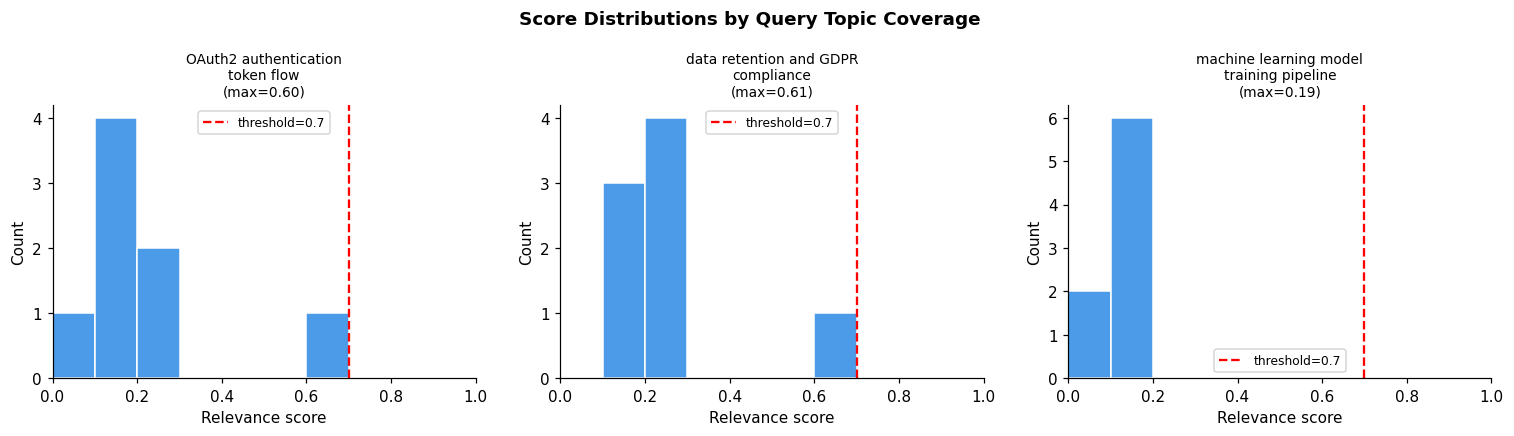

Takeaway:
  Well-covered query: most scores cluster high (bimodal or right-skewed distribution)
  Sparse/absent topic: all scores low and flat — threshold will cut almost everything
  This is why threshold selection should be calibrated per corpus, not hardcoded.


In [31]:
# ─── SOLUTION: Exercise 4 ───

import numpy as np

queries_for_hist = [
    'OAuth2 authentication token flow',         # well-covered in corpus
    'data retention and GDPR compliance',        # moderately covered
    'machine learning model training pipeline',  # NOT in corpus — should be flat/low
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, q in zip(axes, queries_for_hist):
    results_s = vs.similarity_search_with_relevance_scores(q, k=10)
    scores = [s for _, s in results_s]

    ax.hist(scores, bins=10, range=(0, 1), color='#4C9BE8', edgecolor='white')
    ax.axvline(x=0.7, color='red', linestyle='--', linewidth=1.5, label='threshold=0.7')
    ax.set_title(textwrap.fill(q, 25), fontsize=10)
    ax.set_xlabel('Relevance score')
    ax.set_ylabel('Count')
    ax.set_xlim(0, 1)
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    top_score = max(scores)
    ax.set_title(f'{textwrap.fill(q, 25)}\n(max={top_score:.2f})', fontsize=9)

fig.suptitle('Score Distributions by Query Topic Coverage', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Takeaway:')
print('  Well-covered query: most scores cluster high (bimodal or right-skewed distribution)')
print('  Sparse/absent topic: all scores low and flat — threshold will cut almost everything')
print('  This is why threshold selection should be calibrated per corpus, not hardcoded.')


### Exercise 5 — Self-Query Filter Extraction Audit

**Task:** Write 5 natural language queries. For each, **predict** what filter dict the `SelfQueryRetriever` will generate. Then run them with `verbose=True` and compare your predictions against the actual generated filters.

*Goal:* Develop intuition for how the LLM maps natural language to structured filters, and where it makes surprising or incorrect choices (e.g., extracting a version number from phrases like 'the latest version').


In [33]:
# ─── SOLUTION: Exercise 5 ───
# Predicted filters are subjective — adjust based on what YOU expected

audit_queries = [
    # (query,  your_predicted_filter)
    ('Show me technical documentation',
     {'category': 'technical'}),

    # Changed from 'released in January 2025' — date-range queries cause the
    # SelfQueryRetriever lark parser to generate gte()/lt() compound expressions
    # which its own grammar cannot parse.  Use a version filter instead.
    ('Find API documentation for version 2.1',
     {'category': 'technical', 'version': 'v2.1'}),

    ('What legal agreements cover data processing?',
     {'category': 'legal'}),

    ('Explain the volume discount structure for high-volume API customers',
     {'category': 'financial'}),

    ('What does Platform Engineering say about token lifetimes?',
     {'entities': 'Platform Engineering', 'category': 'technical'}),
]

print(f'{"="*70}')
print('SELF-QUERY FILTER AUDIT')
print(f'{"="*70}')

for q, predicted in audit_queries:
    print(f'\nQuery: {q!r}')
    print(f'  Predicted filter: {predicted}')
    # verbose=True will print the actual generated filter
    try:
        results = sq_retriever.invoke(q)
        cats = [d.metadata.get('category', '?') for d in results]
        print(f'  Result count: {len(results)}  |  Categories: {cats}')
    except Exception as e:
        # The LLM may generate a filter expression the lark parser can't handle
        # (e.g. gte()/lt() range chains).  Surface the failure without crashing.
        print(f'  [Parser error — LLM generated an unsupported filter]: {type(e).__name__}')
    print()

print()
print('Discussion points:')
print('1. Does the LLM always pick the right category from free-form language?')
print('2. Does it extract entity names reliably from indirect references?')
print('3. When the query is ambiguous (e.g., "API access"), does it over-filter or under-filter?')
print('4. Does it fail silently (returns 0 results) when the generated filter has no matches?')


SELF-QUERY FILTER AUDIT

Query: 'Show me technical documentation'
  Predicted filter: {'category': 'technical'}
  Result count: 2  |  Categories: ['technical', 'technical']


Query: 'Find API documentation for version 2.1'
  Predicted filter: {'category': 'technical', 'version': 'v2.1'}
  Result count: 1  |  Categories: ['technical']


Query: 'What legal agreements cover data processing?'
  Predicted filter: {'category': 'legal'}
  Result count: 2  |  Categories: ['legal', 'legal']


Query: 'Explain the volume discount structure for high-volume API customers'
  Predicted filter: {'category': 'financial'}
  Result count: 5  |  Categories: ['financial', 'financial', 'technical', 'technical', 'general']


Query: 'What does Platform Engineering say about token lifetimes?'
  Predicted filter: {'entities': 'Platform Engineering', 'category': 'technical'}
  Result count: 0  |  Categories: []


Discussion points:
1. Does the LLM always pick the right category from free-form language?
2. Does i